# Phase 1 — YOLOv8 추론 및 모델 크기별 벤치마크

목표: n/s/m 모델의 FPS, 파라미터 수, 검출 결과를 비교한다.

In [1]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.5.1+cu121
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 1. 단일 이미지 추론

In [2]:
from ultralytics import YOLO
from IPython.display import Image, display

model = YOLO("yolov8n.pt")

# SOURCE = "https://ultralytics.com/images/bus.jpg"
SOURCE_LOCAL = "bus.jpg"
# results = model(SOURCE, save=True, conf=0.5)
results = model(SOURCE_LOCAL, save=True, conf=0.25)

print(f"len(results) : {len(results)}")
# 검출 결과 요약
for r in results:
    print(f"검출 객체 수: {len(r.boxes)}")
    for box in r.boxes:
        cls_id = int(box.cls)
        conf = float(box.conf)
        print(f"  {model.names[cls_id]}: {conf:.2f}")


image 1/1 c:\coding\my-github-repository\yolo-edge-mastery\01_yolo_basics\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 120.2ms
Speed: 3.4ms preprocess, 120.2ms inference, 19.3ms postprocess per image at shape (1, 3, 640, 480)
Results saved to C:\coding\my-github-repository\yolo-edge-mastery\01_yolo_basics\runs\detect\predict-8
len(results) : 1
검출 객체 수: 6
  bus: 0.87
  person: 0.87
  person: 0.85
  person: 0.83
  person: 0.26
  stop sign: 0.26


In [4]:
import glob
imgs = sorted(glob.glob("runs/detect/predict*/*.jpg"))
for p in imgs:
    print(p)


runs/detect\predict-2\bus.jpg
runs/detect\predict-3\bus.jpg
runs/detect\predict-4\bus.jpg
runs/detect\predict-5\bus.jpg
runs/detect\predict-6\bus.jpg
runs/detect\predict-7\bus.jpg
runs/detect\predict-8\bus.jpg
runs/detect\predict\bus.jpg


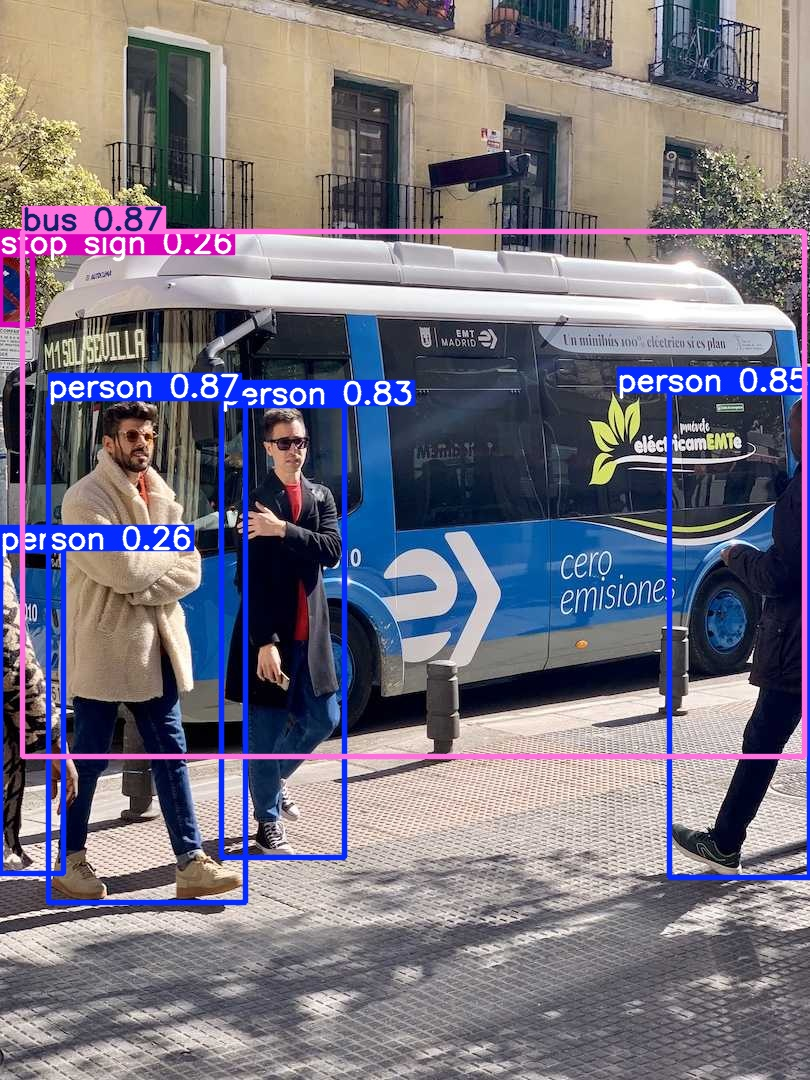

In [5]:
# 결과 이미지 인라인 표시
# import glob
# result_img = sorted(glob.glob("runs/detect/predict*/*.jpg"))[-1]
# display(Image(result_img))
import glob, os
imgs = glob.glob("runs/detect/predict*/*.jpg")
result_img = max(imgs, key=os.path.getmtime)
display(Image(result_img))


## 2. 모델 크기별 FPS / 파라미터 수 벤치마크

In [6]:
import time
import pandas as pd

MODEL_NAMES = ["yolov8n", "yolov8s", "yolov8m"]
N_RUNS = 100

rows = []
for name in MODEL_NAMES:
    m = YOLO(f"{name}.pt")
    m(SOURCE_LOCAL, verbose=False)  # 워밍업

    start = time.perf_counter()
    for _ in range(N_RUNS):
        m(SOURCE_LOCAL, verbose=False)
    elapsed = time.perf_counter() - start

    fps = N_RUNS / elapsed
    params = sum(p.numel() for p in m.model.parameters()) / 1e6
    size_mb = sum(p.numel() * p.element_size() for p in m.model.parameters()) / 1e6

    rows.append({"model": name, "params(M)": round(params, 1), "size(MB)": round(size_mb, 1), "FPS": round(fps, 1)})
    print(f"{name}: {fps:.1f} FPS | {params:.1f}M params")

df = pd.DataFrame(rows)
df

yolov8n: 60.2 FPS | 3.2M params
yolov8s: 60.9 FPS | 11.2M params
yolov8m: 51.4 FPS | 25.9M params


,model,params(M),size(MB),FPS
0,yolov8n,3.2,12.6,60.2
1,yolov8s,11.2,44.6,60.9
2,yolov8m,25.9,103.5,51.4


In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(df["model"], df["FPS"], color="steelblue")
ax1.set_title("FPS by Model Size")
ax1.set_ylabel("FPS")

ax2.bar(df["model"], df["params(M)"], color="coral")
ax2.set_title("Parameters by Model Size")
ax2.set_ylabel("Params (M)")

plt.tight_layout()
plt.savefig("../benchmarks/phase1_model_comparison.png", dpi=150)
plt.show()

In [ ]:
# benchmarks/results.csv 에 기록
import csv
from pathlib import Path

csv_path = Path("../benchmarks/results.csv")
with open(csv_path, "a", newline="") as f:
    writer = csv.writer(f)
    for row in rows:
        writer.writerow([row["model"], "baseline", "phase1", "FPS", "-", row["FPS"], "-", ""])
        writer.writerow([row["model"], "baseline", "phase1", "params_M", "-", row["params(M)"], "-", ""])

print("benchmarks/results.csv 업데이트 완료")

#mAP 측정

In [ ]:
# mAP 측정 (coco128 validation)
results = model.val(data="coco128.yaml")
print(f"mAP@0.5:     {results.box.map50:.3f}")
print(f"mAP@0.5:0.95:{results.box.map:.3f}")


## 3. 모델 크기별 mAP 비교

In [ ]:
for name in ["yolov8s", "yolov8m"]:
    m = YOLO(f"{name}.pt")
    r = m.val(data="coco128.yaml", verbose=False)
    print(f"{name} | mAP@0.5: {r.box.map50:.3f} | mAP@0.5:0.95: {r.box.map:.3f}")


In [8]:
# v9, v11 FPS 벤치마크
for name in ["yolov9s", "yolo11n", "yolo11s"]:
    m = YOLO(f"{name}.pt")
    m("bus.jpg", verbose=False)  # 워밍업

    start = time.perf_counter()
    for _ in range(100):
        m("bus.jpg", verbose=False)
    elapsed = time.perf_counter() - start

    fps = 100 / elapsed
    params = sum(p.numel() for p in m.model.parameters()) / 1e6
    size_mb = sum(p.numel() * p.element_size() for p in m.model.parameters()) / 1e6
    print(f"{name}: {fps:.1f} FPS | {params:.1f}M params | {size_mb:.1f}MB")


yolov9s: 29.0 FPS | 7.2M params | 28.8MB
yolo11n: 47.9 FPS | 2.6M params | 10.5MB
yolo11s: 48.4 FPS | 9.4M params | 37.8MB


In [ ]:
for name in ["yolov9s", "yolo11n", "yolo11s"]:
    m = YOLO(f"{name}.pt")
    # workers=0 옵션을 주어 윈도우 멀티프로세싱 버그를 방지합니다.
    r = m.val(data="coco128.yaml", verbose=False, workers=0)
    print(f"{name} | mAP@0.5: {r.box.map50:.3f} | mAP@0.5:0.95: {r.box.map:.3f}")


Ultralytics 8.4.75  Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLOv9s summary (fused): 197 layers, 7,198,048 parameters, 0 gradients, 26.9 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 113.947.1 MB/s, size: 71.5 KB)
val: Scanning C:\coding\github-repository\portfolio\datasets\coco128\labels\train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128  0.0s
